# Ensemble Inference & Visualization
Loads all 5 fold checkpoints, runs sliding-window ensemble inference on a selected case, and visualizes the CT + predicted segmentation overlay.

## 1. Mount Azure Data

In [19]:
# %pip install azureml-dataset-runtime
from azureml.core import Workspace, Dataset
from pathlib import Path
import os

# 1. Connect to your workspace (v1 syntax)
ws = Workspace(
    subscription_id="ab211f7b-463f-4833-9605-d260e596a35a",
    resource_group="73da10b4-5dff-54e2-db0d-3a1fab882485",
    workspace_name="73da10b45dff54e2db0d3a1fab882485"
)

# 2. Get your datastore
datastore = ws.datastores["73da10b45dff54e2db0d3a1fab882485"]

# 3. Create a dataset reference to your root NIFTI folder
nifti_dataset = Dataset.File.from_files(path=(datastore, 'NIFTI/DATA_REGISTERED_FIXED_LATE'))

# 4. Download the dataset locally instead of mounting it
local_mount_path = Path("./nifti_data").resolve()
local_mount_path.mkdir(parents=True, exist_ok=True)
# nifti_dataset.download(target_path=str(local_mount_path), overwrite=True)

# 5. Get the actual local OS path
local_mount_path = str(local_mount_path)
print(f"Data successfully downloaded to: {local_mount_path}")

# Verify by listing the folders inside the download
print(os.listdir(local_mount_path)[:5])

Data successfully downloaded to: /Users/ricca/Desktop/Health_Informatics_Internship_Team2/notebooks/nifti_data
['TAVI_098', 'TAVI_054', 'TAVI_266', 'TAVI_096', 'TAVI_062']


## 2. Configuration
Edit the cells below to point to your checkpoint folder and select a patient.

In [20]:
from pathlib import Path

user = "barichella.riccardo"  # replace with your Azure username (without @domain)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

azure_checkpoint_root = Path("/home/azureuser/cloudfiles/code/Users") / user / "Health_Informatics_Internship_2026" / "outputs-only-dice-1"
checkpoint_root_candidates = [
    azure_checkpoint_root,
    PROJECT_ROOT / "outputs-only-dice-1",
    PROJECT_ROOT / "notebooks" / "output" / "named-outputs" / "output_model",
    PROJECT_ROOT / "output" / "named-outputs" / "output_model",
    PROJECT_ROOT / "outputs",
]
CHECKPOINTS_ROOT = next(
    (path for path in checkpoint_root_candidates if path.exists() and any(path.glob("**/*.pth"))),
    azure_checkpoint_root,
)

# Set to a patient name (e.g. "TAVI_095") to pin a specific case,
# or leave as None to auto-select an unseen patient.
CASE_NAME = "TAVI_290"

FOLD_COUNT      = None  # auto-detect available folds from CHECKPOINTS_ROOT
TARGET_SPACING  = (1.0, 1.0, 1.0)   # must match train_config.yaml
ROI_SIZE        = (96, 96, 96)
SW_BATCH_SIZE   = 4
OVERLAP         = 0.8
SEED            = 1303
UNSEEN_OFFSET   = 200
OUTPUT_DIR      = PROJECT_ROOT / "notebooks" / "output" / "named-outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Imports

In [21]:
# %pip install torch
%pip install nibabel
%pip install monai

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import re
import random
from contextlib import nullcontext

import numpy as np
import torch
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from monai.networks.nets import SegResNet
from monai.inferers import sliding_window_inference
from monai.data import Dataset, DataLoader, MetaTensor, decollate_batch
from monai.transforms import (
    AsDiscreted, Compose, CropForegroundd, EnsureChannelFirstd,
    Invertd, LoadImaged, Orientationd, SaveImaged,
    ScaleIntensityRanged, Spacingd,
)

# Set up device and mixed precision context. If running on Apple Silicon, you may want to set device to "mps" and adjust the autocast context accordingly.

#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#amp_ctx = torch.amp.autocast("cuda") if device.type == "cuda" else nullcontext()
#print(f"Using device: {device}")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
amp_ctx = torch.amp.autocast("mps") if device.type == "mps" else nullcontext()
print(f"Using device: {device}")

Using device: cpu


## 4. Case Selection

In [23]:
PATIENT_PATTERN = re.compile(r"^TAVI_\d+$")
DATA_ROOT = Path(local_mount_path)

def find_valid_cases(input_dir):
    cases = []
    for folder in sorted(Path(input_dir).iterdir()):
        if folder.is_dir() and PATIENT_PATTERN.match(folder.name):
            img = folder / "CT_LATE.nii.gz"
            lbl = folder / "registration_mask.nii.gz"
            if img.exists() and lbl.exists():
                cases.append({"image": str(img), "label": str(lbl), "name": folder.name})
    return cases

def select_case(cases, case_name=None, seed=1303, unseen_offset=200):
    if case_name:
        match = [c for c in cases if c["name"] == case_name]
        if not match:
            raise ValueError(f"Case '{case_name}' not found.")
        return match[0]
    shuffled = list(cases)
    random.seed(seed)
    random.shuffle(shuffled)
    return shuffled[min(unseen_offset, len(shuffled) - 1)]

all_cases = find_valid_cases(DATA_ROOT)
test_case = select_case(all_cases, CASE_NAME, SEED, UNSEEN_OFFSET)
print(f"Selected patient : {test_case['name']}")
print(f"Image            : {test_case['image']}")
print(f"Label            : {test_case['label']}")

Selected patient : TAVI_290
Image            : /Users/ricca/Desktop/Health_Informatics_Internship_Team2/notebooks/nifti_data/TAVI_290/CT_LATE.nii.gz
Label            : /Users/ricca/Desktop/Health_Informatics_Internship_Team2/notebooks/nifti_data/TAVI_290/registration_mask.nii.gz


## 5. Checkpoint Collection

In [24]:
def collect_checkpoints(root, fold_count):
    root = Path(root)
    if not root.exists():
        project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
        fallback_roots = [
            project_root / "notebooks" / "output" / "named-outputs" / "output_model",
            project_root / "output" / "named-outputs" / "output_model",
            project_root / "outputs-only-dice-1",
            project_root / "outputs",
        ]
        root = next((path for path in fallback_roots if path.exists() and any(path.glob("**/*.pth"))), root)
    if not root.exists():
        raise FileNotFoundError(f"Checkpoint root does not exist: {root}")
    if fold_count is None:
        fold_indices = sorted(
            {
                int(part.split("_", 1)[1])
                for path in root.glob("**/*.pth")
                for part in path.parts
                if part.startswith("fold_") and part.split("_", 1)[1].isdigit()
            }
        )
        if not fold_indices:
            raise FileNotFoundError(f"No fold checkpoints found under: {root}")
    else:
        fold_indices = list(range(fold_count))
    paths, missing = [], []
    for i in fold_indices:
        candidates = [
            *sorted(root.glob(f"**/fold_{i}/checkpoints/best.pth")),
            *sorted(root.glob(f"**/fold_{i}/checkpoints/latest.pth")),
            root / f"fold{i}" / "named-outputs" / "output_model" / f"fold_{i}" / "checkpoints" / "best.pth",
            root / f"fold_{i}" / "checkpoints" / "best.pth",
            root / f"fold_{i}" / "checkpoints" / "latest.pth",
            root / f"fold{i}" / "named-outputs" / "output_model" / f"fold_{i}" / "best_metric_model.pth",
            root / f"fold_{i}" / "best_metric_model.pth",
            root / f"fold_{i}" / "named-outputs" / "output_model" / "best_metric_model.pth",
            root / f"fold_{i}" / "named-outputs" / "output_model" / f"fold_{i}" / "latest_checkpoint.pth",
        ]
        found = next((p for p in candidates if p.exists()), None)
        (paths if found else missing).append(found or candidates[0])
    if missing:
        raise FileNotFoundError("Missing checkpoints:\n" + "\n".join(str(p) for p in missing))
    globals()["CHECKPOINTS_ROOT"] = root
    return paths

checkpoint_paths = collect_checkpoints(CHECKPOINTS_ROOT, FOLD_COUNT)
FOLD_COUNT = len(checkpoint_paths)
print(f"Checkpoint root: {CHECKPOINTS_ROOT}")
print(f"Folds found: {FOLD_COUNT}")
print("Checkpoints found:")
for p in checkpoint_paths:
    print(" ", p)

Checkpoint root: /Users/ricca/Desktop/Health_Informatics_Internship_Team2/notebooks/output/named-outputs/output_model
Folds found: 1
Checkpoints found:
  /Users/ricca/Desktop/Health_Informatics_Internship_Team2/notebooks/output/named-outputs/output_model/fold_0/best_metric_model.pth


## 6. Transforms

In [25]:
infer_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    CropForegroundd(keys=["image"], source_key="image"),
    Spacingd(keys=["image"], pixdim=TARGET_SPACING, mode=("bilinear",)),
    ScaleIntensityRanged(
        keys=["image"], a_min=-100.0, a_max=400.0,
        b_min=0.0, b_max=1.0, clip=True,
    ),
])

post_transforms = Compose([
    Invertd(
        keys="pred",
        transform=infer_transforms,
        orig_keys="image",
        meta_keys="pred_meta_dict",
        orig_meta_keys="image_meta_dict",
        meta_key_postfix="meta_dict",
        nearest_interp=False,
        to_tensor=True,
    ),
    AsDiscreted(keys="pred", argmax=True),
])

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


## 7. Model & Ensemble Inference

In [26]:
import inspect
import sys


def load_checkpoint(model, path, device):
    load_kwargs = {"map_location": device}
    try:
        if "weights_only" in inspect.signature(torch.load).parameters:
            load_kwargs["weights_only"] = False
    except (TypeError, ValueError):
        pass

    if hasattr(np, "core"):
        sys.modules["numpy._core"] = np.core
        sys.modules["numpy._core.multiarray"] = np.core.multiarray

    ckpt = torch.load(path, **load_kwargs)
    sd = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
    sd = {k[7:] if k.startswith("module.") else k: v for k, v in sd.items()}
    model.load_state_dict(sd)
    model.eval()


model = SegResNet(
    spatial_dims=3, in_channels=1, out_channels=2,
    init_filters=16, blocks_down=[1, 2, 2, 4], blocks_up=[1, 1, 1],
).to(device)

# We store raw ensemble probs so we can visualise uncertainty later
ds = Dataset(data=[test_case], transform=infer_transforms)
loader = DataLoader(ds, batch_size=1)

ensemble_probs_np = None
preprocessed_input_np = None

with torch.inference_mode():
    for batch in loader:
        inputs = batch["image"].to(device)
        preprocessed_input_np = batch["image"].numpy()[0, 0]  # (H, W, D)

        ensemble_probs = None
        for i, ckpt_path in enumerate(checkpoint_paths):
            print(f"  Running fold {i} ...")
            load_checkpoint(model, ckpt_path, device)
            with amp_ctx:
                logits = sliding_window_inference(
                    inputs, ROI_SIZE, SW_BATCH_SIZE, model, overlap=OVERLAP
                )
                probs = torch.softmax(logits, dim=1)
            ensemble_probs = probs if ensemble_probs is None else ensemble_probs + probs

        ensemble_probs = ensemble_probs / len(checkpoint_paths)
        ensemble_probs_np = ensemble_probs.cpu().numpy()[0]  # (C, H, W, D)

        src_meta = batch["image"].meta if hasattr(batch["image"], "meta") else batch["image_meta_dict"]
        predictions = MetaTensor(ensemble_probs, meta=src_meta)
        batch_data = {"image": batch["image"], "pred": predictions}

        def _to_numpy(x):
            if isinstance(x, torch.Tensor):
                return x.detach().cpu().numpy()
            return x

        for item in decollate_batch(batch_data):
            if "image_meta_dict" not in item:
                item["image_meta_dict"] = item["image"].meta if hasattr(item["image"], "meta") else src_meta
            if "pred_meta_dict" not in item:
                item["pred_meta_dict"] = dict(item["image_meta_dict"])
            for k, v in list(item["pred_meta_dict"].items()):
                try:
                    item["pred_meta_dict"][k] = _to_numpy(v)
                except Exception:
                    pass

            item = post_transforms(item)

            pred_np = item["pred"].detach().cpu().numpy()
            if pred_np.ndim == 4 and pred_np.shape[0] == 1:
                pred_np = pred_np[0]

            pred_meta = item.get("pred_meta_dict") or item.get("image_meta_dict") or src_meta
            image_meta = item.get("image_meta_dict") or src_meta
            if not isinstance(pred_meta, dict):
                pred_meta = dict(pred_meta)
            if not isinstance(image_meta, dict):
                image_meta = dict(image_meta)

            affine = pred_meta.get("affine")
            if affine is None:
                affine = image_meta.get("affine")
            if affine is None:
                affine = np.eye(4)
            out_path = OUTPUT_DIR / f"{test_case['name']}_pred_mask.nii.gz"
            nib.save(nib.Nifti1Image(pred_np.astype(np.uint8), affine=np.asarray(affine)), str(out_path))

print(f"\nSaved prediction to: {OUTPUT_DIR}")

# Binary prediction mask (preprocessed space, for visualisation)
pred_mask_np = np.argmax(ensemble_probs_np, axis=0)  # (H, W, D)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
  Running fold 0 ...


numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1769685250281/work/torch/csrc/autograd/python_variable_indexing.cpp:353.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed 


Saved prediction to: inference_results_ensemble


## 8. Load Ground Truth (in preprocessed space for fair comparison)

In [27]:
# Apply the same preprocessing pipeline to the label so it aligns with the prediction
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, Orientationd, CropForegroundd,
    Spacingd, ScaleIntensityRanged, Compose,
)

val_transforms_with_label = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    Spacingd(keys=["image", "label"], pixdim=TARGET_SPACING, mode=("bilinear", "nearest")),
    ScaleIntensityRanged(
        keys=["image"], a_min=-100.0, a_max=400.0,
        b_min=0.0, b_max=1.0, clip=True,
    ),
])

sample = val_transforms_with_label(test_case)
ct_vol   = sample["image"].numpy()[0]   # (H, W, D)
gt_mask  = sample["label"].numpy()[0].astype(int)  # (H, W, D)

print(f"Volume shape  : {ct_vol.shape}")
print(f"Prediction    : {pred_mask_np.shape}")
print(f"Ground truth  : {gt_mask.shape}")
print(f"GT unique vals: {np.unique(gt_mask)}")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Volume shape  : (162, 162, 136)
Prediction    : (162, 162, 136)
Ground truth  : (162, 162, 136)
GT unique vals: [0 1]


## 9. Metrics

In [28]:
def dice_score_binary(pred_mask, gt_mask):
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)
    denom = pred_mask.sum() + gt_mask.sum()
    if denom == 0:
        return 1.0
    return 2.0 * np.logical_and(pred_mask, gt_mask).sum() / denom

def surface_voxels(mask):
    mask = mask.astype(bool)
    if not mask.any():
        return np.empty((0, 3), dtype=np.int32)

    padded = np.pad(mask, 1, mode="constant", constant_values=False)
    interior = padded[1:-1, 1:-1, 1:-1]
    eroded = interior.copy()
    eroded &= padded[:-2, 1:-1, 1:-1]
    eroded &= padded[2:, 1:-1, 1:-1]
    eroded &= padded[1:-1, :-2, 1:-1]
    eroded &= padded[1:-1, 2:, 1:-1]
    eroded &= padded[1:-1, 1:-1, :-2]
    eroded &= padded[1:-1, 1:-1, 2:]
    surface = interior & ~eroded
    return np.argwhere(surface)

def nearest_surface_distances(source_coords, target_coords, spacing, chunk_size=2048):
    if len(source_coords) == 0 or len(target_coords) == 0:
        return np.array([np.nan])

    source_mm = source_coords.astype(np.float32) * spacing
    target_mm = target_coords.astype(np.float32) * spacing
    distances = []

    for start in range(0, len(source_mm), chunk_size):
        chunk = source_mm[start:start + chunk_size]
        diff = chunk[:, None, :] - target_mm[None, :, :]
        dist_sq = np.sum(diff * diff, axis=2)
        distances.append(np.sqrt(np.min(dist_sq, axis=1)))

    return np.concatenate(distances)

spacing_arr = np.asarray(TARGET_SPACING, dtype=np.float32)
pred_mask = pred_mask_np.astype(bool)
gt_mask_bool = gt_mask.astype(bool)

dice_score = dice_score_binary(pred_mask, gt_mask_bool)

pred_surface = surface_voxels(pred_mask)
gt_surface = surface_voxels(gt_mask_bool)

pred_to_gt = nearest_surface_distances(pred_surface, gt_surface, spacing_arr)
gt_to_pred = nearest_surface_distances(gt_surface, pred_surface, spacing_arr)
all_dist = np.concatenate([pred_to_gt, gt_to_pred])

asd = float(np.clip(np.nan_to_num(np.nanmean(all_dist), nan=500), 0, 500))
hd95 = float(np.clip(np.nan_to_num(np.nanpercentile(all_dist, 95), nan=500), 0, 500))

print(f"Patient  : {test_case['name']}")
print(f"Dice     : {dice_score:.4f}")
print(f"HD95     : {hd95:.2f} mm")
print(f"ASD      : {asd:.2f} mm")

Patient  : TAVI_290
Dice     : 0.9576
HD95     : 1.00 mm
ASD      : 0.46 mm


## 10. Visualisation — Multi-Slice Overlay

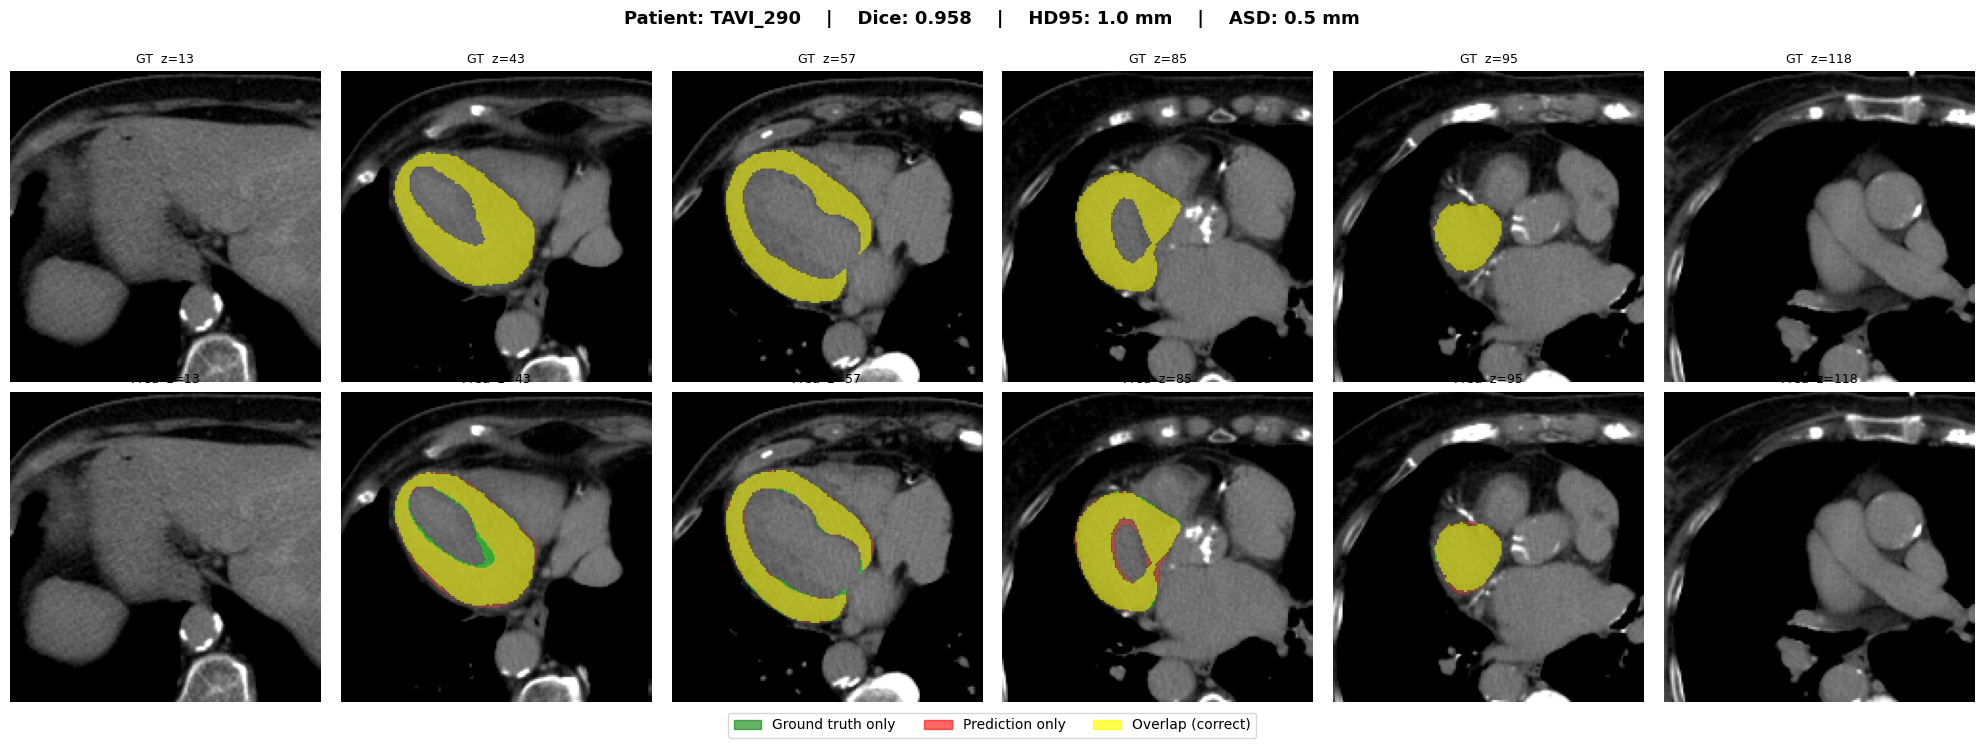

Figure saved to inference_results_ensemble/TAVI_290_overlay.png


In [29]:
def find_best_slices(mask, n=6):
    """Return axial slice indices with the most foreground voxels."""
    counts = mask.sum(axis=(0, 1))
    top = np.argsort(counts)[::-1]
    step = max(1, len(top) // n)
    selected = sorted(top[::step][:n])
    return selected


def overlay_mask(ax, ct_slice, gt_slice, pred_slice, title=""):
    ax.imshow(ct_slice.T, cmap="gray", origin="lower", vmin=0, vmax=1)
    gt_rgba   = np.zeros((*gt_slice.shape,   4))
    pred_rgba = np.zeros((*pred_slice.shape, 4))

    gt_rgba[gt_slice   > 0] = [0.0, 1.0, 0.0, 0.45]   # green  = ground truth
    pred_rgba[pred_slice > 0] = [1.0, 0.2, 0.2, 0.45]  # red    = prediction

    # Overlap region: yellow
    overlap = (gt_slice > 0) & (pred_slice > 0)
    gt_rgba[overlap]   = [1.0, 1.0, 0.0, 0.55]
    pred_rgba[overlap] = [0.0, 0.0, 0.0, 0.0]

    ax.imshow(gt_rgba.transpose(1, 0, 2),   origin="lower")
    ax.imshow(pred_rgba.transpose(1, 0, 2), origin="lower")
    ax.set_title(title, fontsize=9)
    ax.axis("off")


slices = find_best_slices(gt_mask, n=6)
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle(
    f"Patient: {test_case['name']}    |    "
    f"Dice: {dice_score:.3f}    |    HD95: {hd95:.1f} mm    |    ASD: {asd:.1f} mm",
    fontsize=13, fontweight="bold", y=1.01,
)

for col, z in enumerate(slices):
    # Top row: ground truth overlay
    overlay_mask(
        axes[0, col],
        ct_vol[:, :, z], gt_mask[:, :, z], gt_mask[:, :, z],
        title=f"GT  z={z}",
    )
    # Bottom row: prediction overlay
    overlay_mask(
        axes[1, col],
        ct_vol[:, :, z], gt_mask[:, :, z], pred_mask_np[:, :, z],
        title=f"Pred  z={z}",
    )

patches = [
    mpatches.Patch(color="green",  alpha=0.6, label="Ground truth only"),
    mpatches.Patch(color="red",    alpha=0.6, label="Prediction only"),
    mpatches.Patch(color="yellow", alpha=0.7, label="Overlap (correct)"),
]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
overlay_path = OUTPUT_DIR / f"{test_case['name']}_overlay.png"
plt.savefig(overlay_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to {overlay_path}")

## 11. Visualisation — Confidence Map

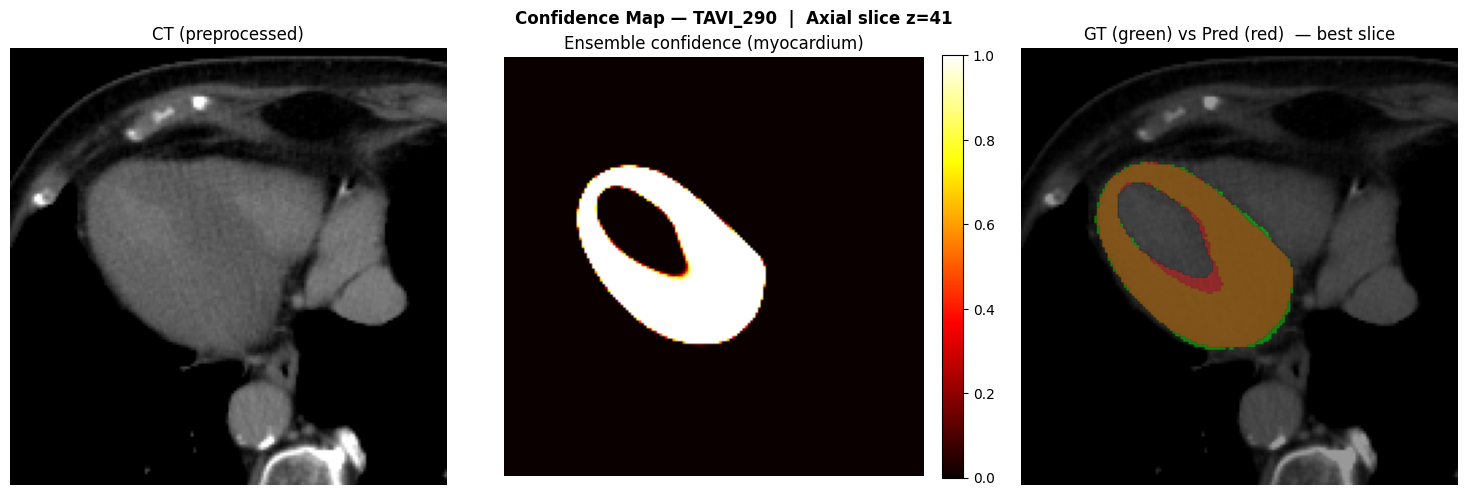

In [30]:
# Ensemble uncertainty = probability of the myocardium class (class 1)
conf_vol = ensemble_probs_np[1]  # (H, W, D), values in [0, 1]

# Pick the slice with highest mean confidence inside the GT region
best_z = int(np.argmax(conf_vol.sum(axis=(0, 1))))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"Confidence Map — {test_case['name']}  |  Axial slice z={best_z}",
    fontsize=12, fontweight="bold",
)

# CT
axes[0].imshow(ct_vol[:, :, best_z].T, cmap="gray", origin="lower", vmin=0, vmax=1)
axes[0].set_title("CT (preprocessed)"); axes[0].axis("off")

# Confidence heat map
im = axes[1].imshow(
    conf_vol[:, :, best_z].T, cmap="hot", origin="lower", vmin=0, vmax=1
)
axes[1].set_title("Ensemble confidence (myocardium)"); axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# Side-by-side: GT vs Pred
compare = np.zeros((*ct_vol[:, :, best_z].shape, 3))
compare[..., 0] = ct_vol[:, :, best_z] * 0.6  # dim red channel as base
compare[..., 1] = ct_vol[:, :, best_z] * 0.6
compare[..., 2] = ct_vol[:, :, best_z] * 0.6

axes[2].imshow(compare.transpose(1, 0, 2), origin="lower")
gt_c   = np.zeros((*gt_mask[:, :, best_z].shape, 4))
pred_c = np.zeros((*pred_mask_np[:, :, best_z].shape, 4))
gt_c[gt_mask[:, :, best_z]         > 0] = [0.0, 0.9, 0.0, 0.5]
pred_c[pred_mask_np[:, :, best_z]  > 0] = [0.9, 0.1, 0.1, 0.5]
axes[2].imshow(gt_c.transpose(1, 0, 2), origin="lower")
axes[2].imshow(pred_c.transpose(1, 0, 2), origin="lower")
axes[2].set_title("GT (green) vs Pred (red)  — best slice"); axes[2].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{test_case['name']}_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Visualisation — 3-Plane View (Axial / Coronal / Sagittal)

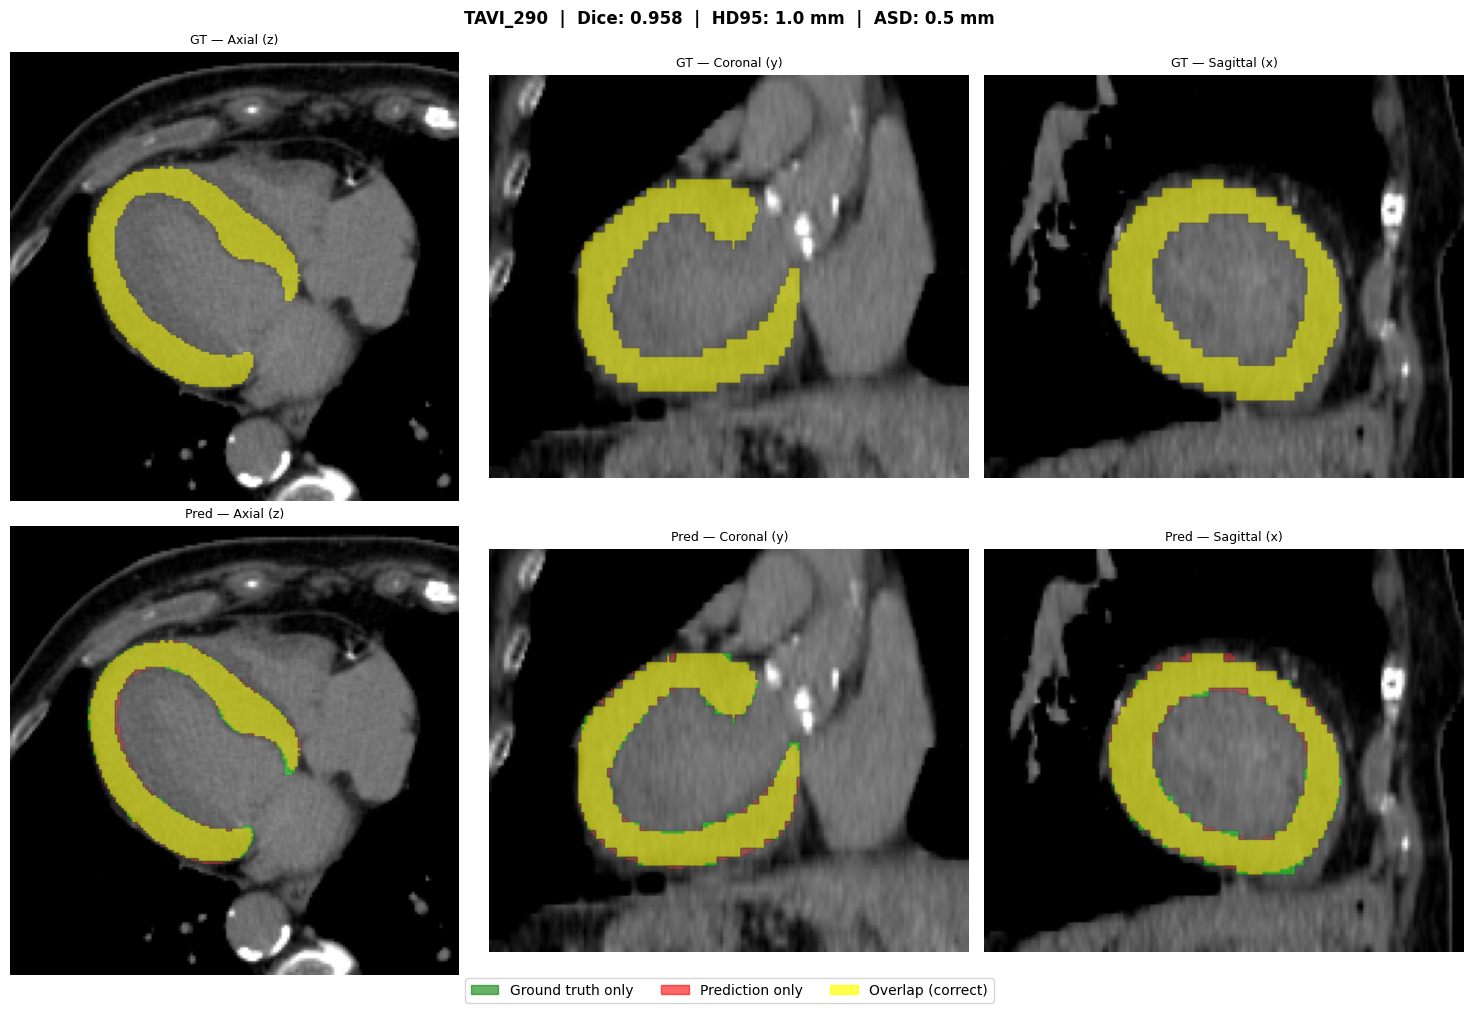

In [31]:
def centroid_slice(mask):
    """Returns (x, y, z) centroid of the foreground mask."""
    coords = np.argwhere(mask > 0)
    if len(coords) == 0:
        mid = np.array(mask.shape) // 2
        return mid[0], mid[1], mid[2]
    return tuple(coords.mean(axis=0).astype(int))

cx, cy, cz = centroid_slice(gt_mask)

planes = [
    ("Axial (z)",    ct_vol[:, :, cz],   gt_mask[:, :, cz],   pred_mask_np[:, :, cz]),
    ("Coronal (y)",  ct_vol[:, cy, :],   gt_mask[:, cy, :],   pred_mask_np[:, cy, :]),
    ("Sagittal (x)", ct_vol[cx, :, :],   gt_mask[cx, :, :],   pred_mask_np[cx, :, :]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(
    f"{test_case['name']}  |  Dice: {dice_score:.3f}  |  HD95: {hd95:.1f} mm  |  ASD: {asd:.1f} mm",
    fontsize=12, fontweight="bold",
)

for col, (plane_name, ct_sl, gt_sl, pred_sl) in enumerate(planes):
    overlay_mask(axes[0, col], ct_sl, gt_sl, gt_sl,   title=f"GT — {plane_name}")
    overlay_mask(axes[1, col], ct_sl, gt_sl, pred_sl, title=f"Pred — {plane_name}")

patches = [
    mpatches.Patch(color="green",  alpha=0.6, label="Ground truth only"),
    mpatches.Patch(color="red",    alpha=0.6, label="Prediction only"),
    mpatches.Patch(color="yellow", alpha=0.7, label="Overlap (correct)"),
]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{test_case['name']}_3plane.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Summary Table

In [32]:
import pandas as pd
from IPython.display import display

gt_voxels   = int(gt_mask.sum())
pred_voxels = int(pred_mask_np.sum())
vox_vol_mm3 = float(np.prod(TARGET_SPACING))

summary = pd.DataFrame([
    {"Metric": "Patient",                   "Value": test_case["name"]},
    {"Metric": "Volume shape",              "Value": str(ct_vol.shape)},
    {"Metric": "Target spacing (mm)",       "Value": str(TARGET_SPACING)},
    {"Metric": "Folds ensembled",           "Value": FOLD_COUNT},
    {"Metric": "Dice (myocardium)",         "Value": f"{dice_score:.4f}"},
    {"Metric": "HD95 (mm)",                 "Value": f"{hd95:.2f}"},
    {"Metric": "ASD (mm)",                  "Value": f"{asd:.2f}"},
    {"Metric": "GT volume (voxels)",        "Value": gt_voxels},
    {"Metric": "Pred volume (voxels)",      "Value": pred_voxels},
    {"Metric": "GT volume (mL)",            "Value": f"{gt_voxels * vox_vol_mm3 / 1000:.1f}"},
    {"Metric": "Pred volume (mL)",          "Value": f"{pred_voxels * vox_vol_mm3 / 1000:.1f}"},
    {"Metric": "Overlap fraction",          "Value": f"{float((gt_mask & pred_mask_np.astype(bool)).sum()) / max(gt_voxels, 1):.3f}"},
])

display(summary.style.hide(axis="index").set_table_styles([
    {"selector": "th", "props": [("background-color", "#2c3e50"), ("color", "white"), ("font-size", "13px")]},
    {"selector": "td", "props": [("font-size", "13px"), ("padding", "6px 12px")]},
    {"selector": "tr:nth-child(even) td", "props": [("background-color", "#f2f2f2")]},
]))

Metric,Value
Patient,TAVI_290
Volume shape,"(162, 162, 136)"
Target spacing (mm),"(1.0, 1.0, 1.0)"
Folds ensembled,1
Dice (myocardium),0.9576
HD95 (mm),1.00
ASD (mm),0.46
GT volume (voxels),141918
Pred volume (voxels),142493
GT volume (mL),141.9


## 14. (Optional) Unmount

In [33]:
if "mount_context" in globals() and mount_context is not None:
    mount_context.stop()
    print("Azure mount released.")
else:
    print("No Azure mount active.")

No Azure mount active.
